# Tutorials

Here we present examples on how MieNet can be used.


## AI Models

ANN predictions provide fast and accurate opacity calculations. To see how to predict efficiences using MieNet's ANNs, skip to Step 4. Making your own AI model requires a large training dataset and hyperparameter tuning.

### Step 1: Creating a training set

Training set inputs:
- wavelength sample
- cloud particle size sample
- volume mixing ratios

The smaller your wavelengths and particle sizes are and the smaller amount of materials in your mixture, the smaller your training set will need to be. The total training set size is equal to (number of wavelengths) * (number of particle sizes). Wavelengths and volume mixing ratios will be randomly sampled, and particle sizes are sampled in a fixed grid. MieNet's function to produce a training set saves it as an xarray.Dataset, and allows users to stop and continue generating data until the dataset is full:

In [1]:
import numpy as np
from mienet import MieNet

# import mienet
ma = MieNet(default_model_location = 'tutorial_files/')
    # default option is default_model_location = None to save in models folder
    # OR set default_model_location = 'path/to/your/folder/' for specific folder

# determine file name, materials, and mixing theory
file = 'tutorial_training_set'
species = ['Fe', 'Mg2SiO4']
mixing_theory = 'LLL' # optional, either LLL (default) or Bruggeman

# determine particle size & wavelength sampling
radii_sampling = (0.001, 0.01, 5) # (min particle size, max particle size, number of radii points)
wavelength_sampling = (0.01, 50, 20) # (min wavelength, max wavelength, number of wavelength points)
    # number of radii points and wavelength points are low for tutorial and small ranges, 1000+ recommended

# generate dataset
ma.generate_training_set(file, species, wavelength_sampling, radii_sampling, mixing_theory)

### Step 2: Training a neural network

MieNet uses TensorFlow (add citation) to train and save AI models. To build a neural network and train it with MieNet, the following is required:
- Training set
- Model file name
- Model parameters

The required model parameters are the model name and number of hidden layers, but there are several optional parameters to customize your model. To train an AI model, use the following function:

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - asymmetry_loss: 2.8920 - asymmetry_mae: 1.3619 - extinction_loss: 1.2870 - extinction_mae: 0.6106 - loss: 5.2331 - scattering_loss: 0.8490 - scattering_mae: 0.7177 - val_asymmetry_loss: 1.0359 - val_asymmetry_mae: 0.8863 - val_extinction_loss: 0.0027 - val_extinction_mae: 0.0307 - val_loss: 1.0427 - val_scattering_loss: 0.0041 - val_scattering_mae: 0.0465
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - asymmetry_loss: 1.1479 - asymmetry_mae: 0.8575 - extinction_loss: 1.1693 - extinction_mae: 0.6153 - loss: 2.9542 - scattering_loss: 0.6624 - scattering_mae: 0.5500 - val_asymmetry_loss: 3.6112 - val_asymmetry_mae: 1.7421 - val_extinction_loss: 0.0466 - val_extinction_mae: 0.2001 - val_loss: 4.4146 - val_scattering_loss: 0.7567 - val_scattering_mae: 0.8384
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - asymmetry_loss: 0.9449 - asymmetry_mae: 0.8443 - extinction_loss: 1.0787 - extinction_mae: 0.6393 - loss: 2.7904 - scattering_loss:

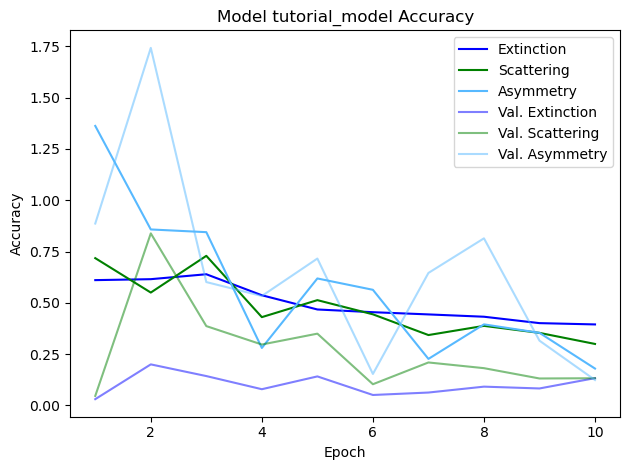

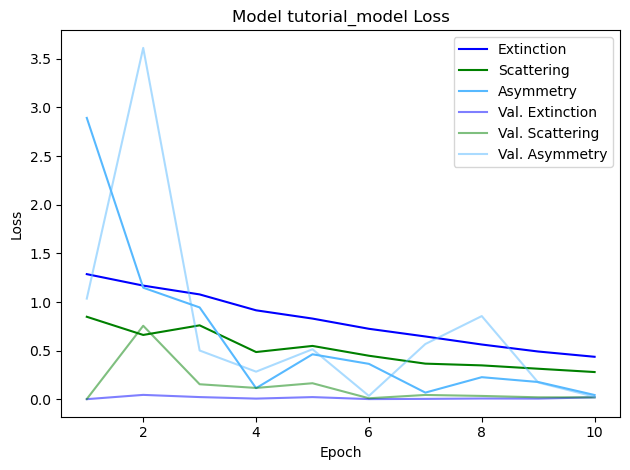

In [2]:
import xarray as xr

# open xarray training set
training_set_path = 'tutorial_files/tutorial_training_set.nc' # path to training set
dataset = xr.open_dataset(training_set_path)
dataset_arr = dataset['data'].to_numpy()

# set model parameters
model_params = {'name': 'tutorial_model', # file name of AI model
                'layers': 2} # number of hidden layers
    # optional parameters: nodes, activation_function, optimizer, loss, metrics, batch_size, and epochs

# train your model
ma.train_ai_model(dataset_arr, model_params, plot_training = True) # plot_training is optional, default is no plotting

### Step 3: Add your ANN to MieNet

In order to use your AI model, you must add the it to the MieNet config.yaml file. This file requires specific formatting, so use the following to add your model:
```
NAME: # choose a name for your model

  architecture: 'one_network' # if using train_ai_model, do not change
  dependencies: {} # if using train_ai_model, do not change

  species: # list the names of each material in mixture in same order given to generate_training_set
    - 'Material 1'
    - 'Material 2'

  range: {'wavelength': (min_wavelength, max_wavelength), 'particle_size': (min_size, max_size)}

  files:
    - 'model_name.keras' # use file name given to train_ai_model function
```

### Step 4: Use ANN Predictions

You are now ready to predict Mie coefficients! Use your own AI model or available MieNet models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mienet import MieNet

# determine model inputs
species =  ['Fe', 'Mg2SiO4']
wavelength_range = np.linspace(0.02, 30, 50)  # microns, within range of model
radius_range = np.linspace(0.01, 0.01, 50)  # microns, within range of model
vmrs = {
    'Fe': 0.5 * np.ones_like(radius_range),
    'Mg2SiO4': 0.5 * np.ones_like(radius_range)}

config_name = 'TUTORIAL_MODEL'

# initialize MieNet again after adding AI model
ma = MieNet(load_ai_model = config_name, default_model_location = 'tutorial_files/', mute = False)
    # set load_ai_model = name of desired model in config file, default is 'all' and loads every model

# predict efficiences
qext, qsca, asym = ma.ai_efficiencies(wavelength_range, radius_range, vmrs)

# plot results
plt.figure()
plt.plot(wavelength_range, np.mean(qext, axis=0))
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Extinction Efficiency')
plt.show()

ValueError: Input 0 of layer "functional" is incompatible with the layer: expected shape=(None, 3), found shape=(1, 2500, 4)

## Grid interpolation

If opacity calculations have to be quick but no AI model is available, Grid interpolation provides a useful alternative. In contrast to AI models, grids are readily created, but take up more storage and are less accurate. Here we show the three steps of grid interpolation.

### Step 1: Creating a grid

To create a grid three things are required:
- wavelength range: Ideally, this should be tailored to your need. A smaller wavelength range helps to reduce the storage space and increases the accuracy.
- cloud particle size range: The default grid is ideal for most applications. However, if you would like higher accuracy you can increase the number of cloud particle radii considered.
- Number of volume mixing ratios: This value determines the accuracy in the mixing between materials and is inverse to the steps in mixing percentage. A value of 20 will result in a 5% accuracy.

The total number of datapoints calculated is equal to (number of wavelengths) * (number of radii) * (number of VMRs)^(number of species - 1). Reducing the number of VMRs is therefore the best way to minimize storage and computation time if more than 2 species are considered. Giving a save file name will save the grid as xarray.Dataset which can later be re-loaded into MieNet. The file name should start with 'grid_' and end with '.nc' to be automatically recognized by MieNet. Producing the grid is done with the following MieNet function:

In [ ]:
import numpy as np
from mienet import Mieai

# import mie ai
ma = Mieai(use_ai=False, mute=False)

# determine grid parameters
species = ['Fe', 'SiO2', 'TiO2']
wavelength_range = np.logspace(0, 1, 200)  # Infrared for cloud feature studies
radius_range = np.logspace(-4, 3.1, 100)  # This is the default value
vmr_points = 3  # This is a low value for the tutorial, 20 or higher is recommended

# calculate grid
ds = ma.produce_efficiency_grid(
    species, wavelengths=wavelength_range,
    particle_sizes=radius_range, vmr_data_points=vmr_points,
    save_file='tutorial_files/grid_tutorial.nc'
)

### Step 2: Load Grid into MieAI

The easiest way to load grids into MieAI is by naming them 'grid_YOURNAME.nc' and storing them in the data folder of MieAI. This way, they will be automatically loaded whenever you initialise the MieAI class. You can also manually load data grids, using the following MieAI functions:

In [2]:
# load grid from file
ma.load_grid_efficiency(file_name='tutorial_files/grid_tutorial.nc')

# load grid from dataset
ma.load_grid_efficiency(ds_grid=ds, ds_grid_name='test_grid')

[INFO] Added grid for ['Fe', 'SiO2', 'TiO2'] from 1.0 to 10.0 micron.


### Step 3: You are ready to use grid interpolation

Now you are ready to use the grid interpolation fucntion of MieAi!

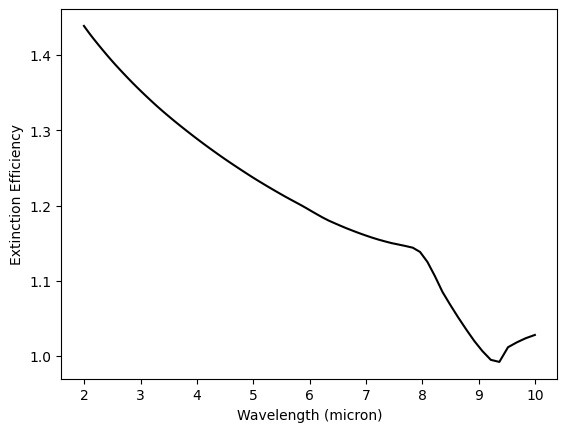

In [5]:
import matplotlib.pyplot as plt

# determine grid parameters
species = ['Fe', 'SiO2', 'TiO2']
wavelength_range = np.logspace(0.3, 1, 100)  # Infrared for cloud feature studies
radius_range = np.logspace(-3, 2, 100)  # This is the default value
vmrs = {
    'Fe': 0.2 * np.ones_like(radius_range),
    'SiO2': 0.5 * np.ones_like(radius_range),
    'TiO2': 0.3 * np.ones_like(radius_range),
}

# get efficiencies from grid interpolation
qext, qsca, asym = ma.grid_efficiencies(wavelength_range, radius_range, vmrs)

# plot results
plt.figure()
plt.plot(wavelength_range, np.mean(qext, axis=0), 'k')
plt.xlabel('Wavelength (micron)')
plt.ylabel('Extinction Efficiency')
plt.show()

To increase the accuracy of the grid interpolation, the number of VMR and wavelength data points can be increased. However, both lead to large grid files and it might take a long time to create the datasets.